this notebook is mostly copied and pasted from the SEGWO tutorial
by Jean Baptiste Bayle and collaborators

see [https://gitlab.com/j2b.bayle/segwo](https://gitlab.com/j2b.bayle/segwo)

Note that this is package has been designed to be very flexible and can handle other TDI combinations, other GW observatories, etc

# Setup

In [2]:
import lisaorbits
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from lisaconstants import c
from lisaconstants.indexing import LINKS
from pytdi.core import LISATDICombination
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

# Make sure mypy correctly types those variables
X2_ETA: LISATDICombination
Y2_ETA: LISATDICombination
Z2_ETA: LISATDICombination

import segwo

# Compute LISA response to an isotropic SGWB

In [3]:
 # Create a static constellation with constant and equal arm lengths
orbits = lisaorbits.StaticConstellation.from_armlengths(2.5e9, 2.5e9, 2.5e9)

# Compute the positions of the spacecraft and the light travel times at t=0.0
ltts = orbits.compute_ltt(t=[0.0])
positions = orbits.compute_position(t=[0.0])

In [4]:
 # Create our frequency grid (in Hertz)
f = np.logspace(-5, 0, 1000)

# Compute the signal covariance matrix for eta variables
signal_cov_eta = segwo.response.compute_isotropic_signal_cov(f, ltts, positions)

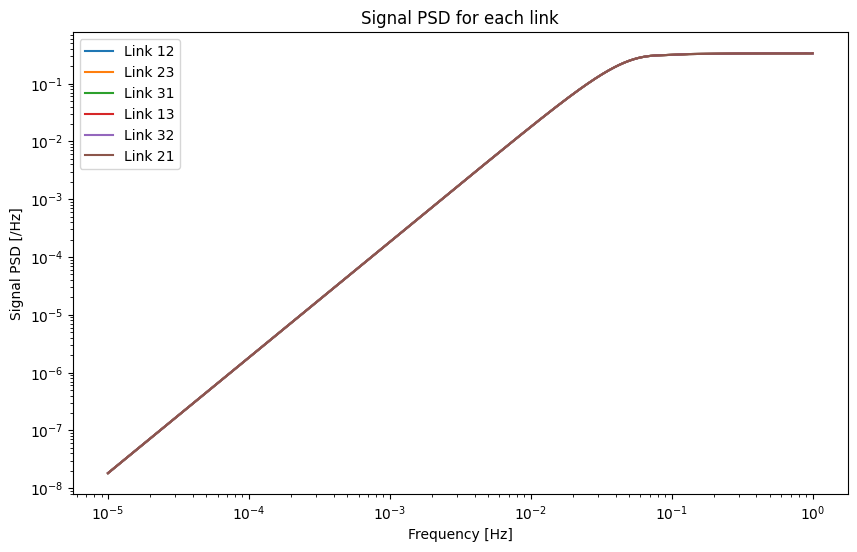

In [5]:
 # Plot the signal PSD for each link
# Because we have a perfectly symmetrical problem (equal-arm constellation and
# isotropic signal), the signal PSD is the same for all links
plt.figure(figsize=(10, 6))
for i, mosa in enumerate(LINKS):
    plt.loglog(f, np.abs(signal_cov_eta[0, :, i, i]), label=f"Link {mosa}")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Signal PSD [/Hz]")
plt.title("Signal PSD for each link")
plt.legend()
plt.show()

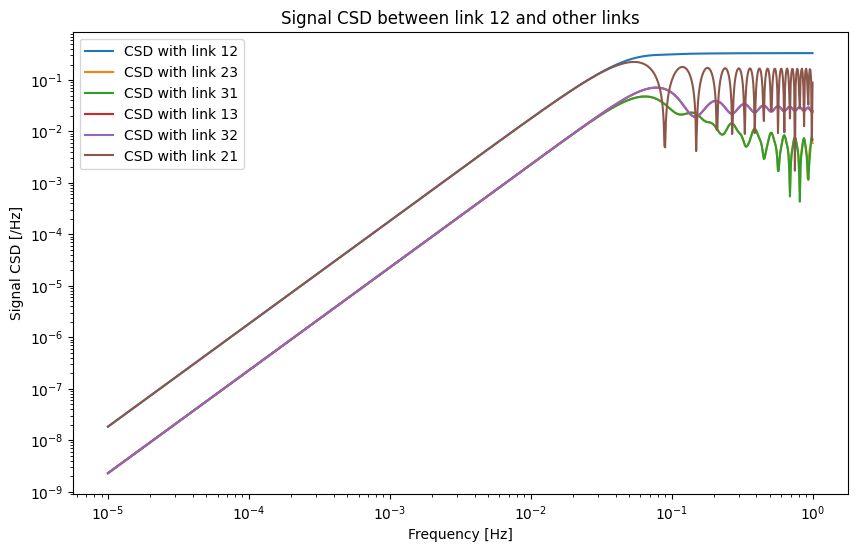

In [6]:
# Plot the signal CSD between link 12 and the other links
plt.figure(figsize=(10, 6))
for i, mosa in enumerate(LINKS):
    plt.loglog(f, np.abs(signal_cov_eta[0, :, 0, i]), label=f"CSD with link {mosa}")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Signal CSD [/Hz]")
plt.title("Signal CSD between link 12 and other links")
plt.legend()
plt.show()

In [7]:
# We form the ordered list of input variables, i.e., the eta variables
eta_list = [f"eta_{mosa}" for mosa in LINKS]

# Then we construct our mixing matrix for X2, Y2, and Z2
eta2xyz = segwo.cov.construct_mixing_from_pytdi(
    f, eta_list, [X2_ETA, Y2_ETA, Z2_ETA], ltts
)

In [8]:
 # We use the mixing matrix to project the eta covariance into the TDI variables
signal_cov_xyz = segwo.cov.project_covariance(signal_cov_eta, eta2xyz)

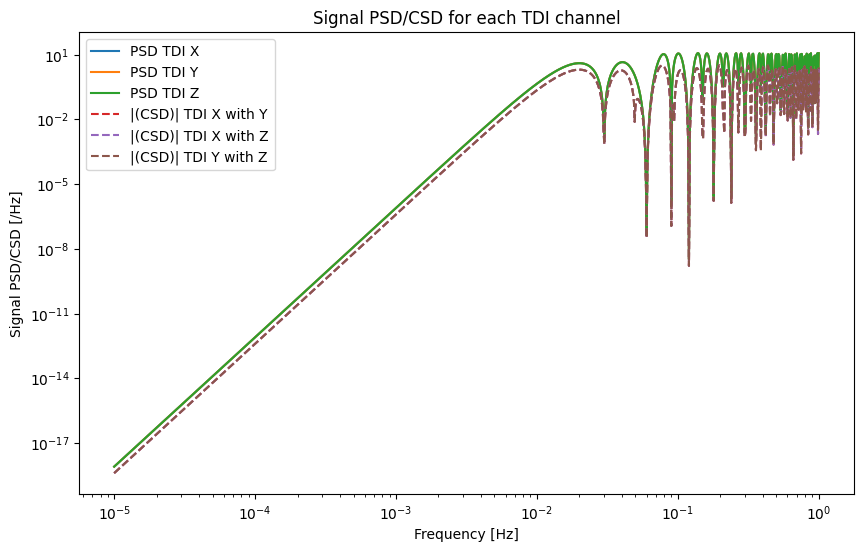

In [16]:
TDI_LABELS = ["X", "Y", "Z"]

plt.figure(figsize=(10, 6))
# Plotting the signal PSD for each TDI channel
for i, tdi in enumerate(TDI_LABELS):
    plt.loglog(f, np.abs(signal_cov_xyz[0, :, i, i]), label=f"PSD TDI {tdi}")

# Plotting the signal CSD between TDI channels
for i, tdi_i in enumerate(TDI_LABELS):
    for j, tdi_j in enumerate(TDI_LABELS):
        if i < j:
            plt.loglog(
                f,
                np.abs((signal_cov_xyz[0, :, i, j])),
                "--",
                label=f"|(CSD)| TDI {tdi_i} with {tdi_j}",
            )
            
plt.xlabel("Frequency [Hz]")
plt.ylabel("Signal PSD/CSD [/Hz]")
plt.title("Signal PSD/CSD for each TDI channel")
plt.legend()
plt.show()

In [17]:
with open('sgwb_response_xyz2.dat','w') as ff:
    ff.write(f"{signal_cov_xyz.shape[1]:d}\n")
    for i in range(signal_cov_xyz.shape[1]):
        line = f"{f[i]:e} {np.real(signal_cov_xyz[0,i,0,0]):e}"
        line+= " "
        line+= f"{np.real(signal_cov_xyz[0,i,1,1]):e}"
        line+= " "
        line+= f"{np.real(signal_cov_xyz[0,i,2,2]):e}"
        line+= " "
        line+= f"{np.real(signal_cov_xyz[0,i,0,1]):e}"
        line+= " "
        line+= f"{np.real(signal_cov_xyz[0,i,0,2]):e}"
        line+= " "
        line+= f"{np.real(signal_cov_xyz[0,i,1,2]):e}"
        #line+= " "
        #line+= f"{better_det_aet[i]:e}"
        line+= "\n"
        ff.write(line)